In [1]:
# ── SETUP ────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math


# Style — professional look
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi']     = 120

# Load processed data — never load raw in EDA
PROCESSED_DIR = Path("../data/processed")
df = pd.read_csv(PROCESSED_DIR / "cleaned_rides.csv", parse_dates=['datetime'])

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Platforms: {df['platform'].unique()}")
print(f"Vehicle classes: {df['vehicle_class'].unique()}")

Loaded 20,569 rows
Date range: 2026-05-04 12:05:00 → 2026-05-11 22:00:00
Platforms: ['PickMe' 'Uber']
Vehicle classes: ['Bike' 'Tuk' 'Economy' 'Standard' 'Premium' 'Parcel_Bike' 'Parcel_Tuk']


Shared vehicle classes: ['Bike', 'Economy', 'Premium', 'Tuk']


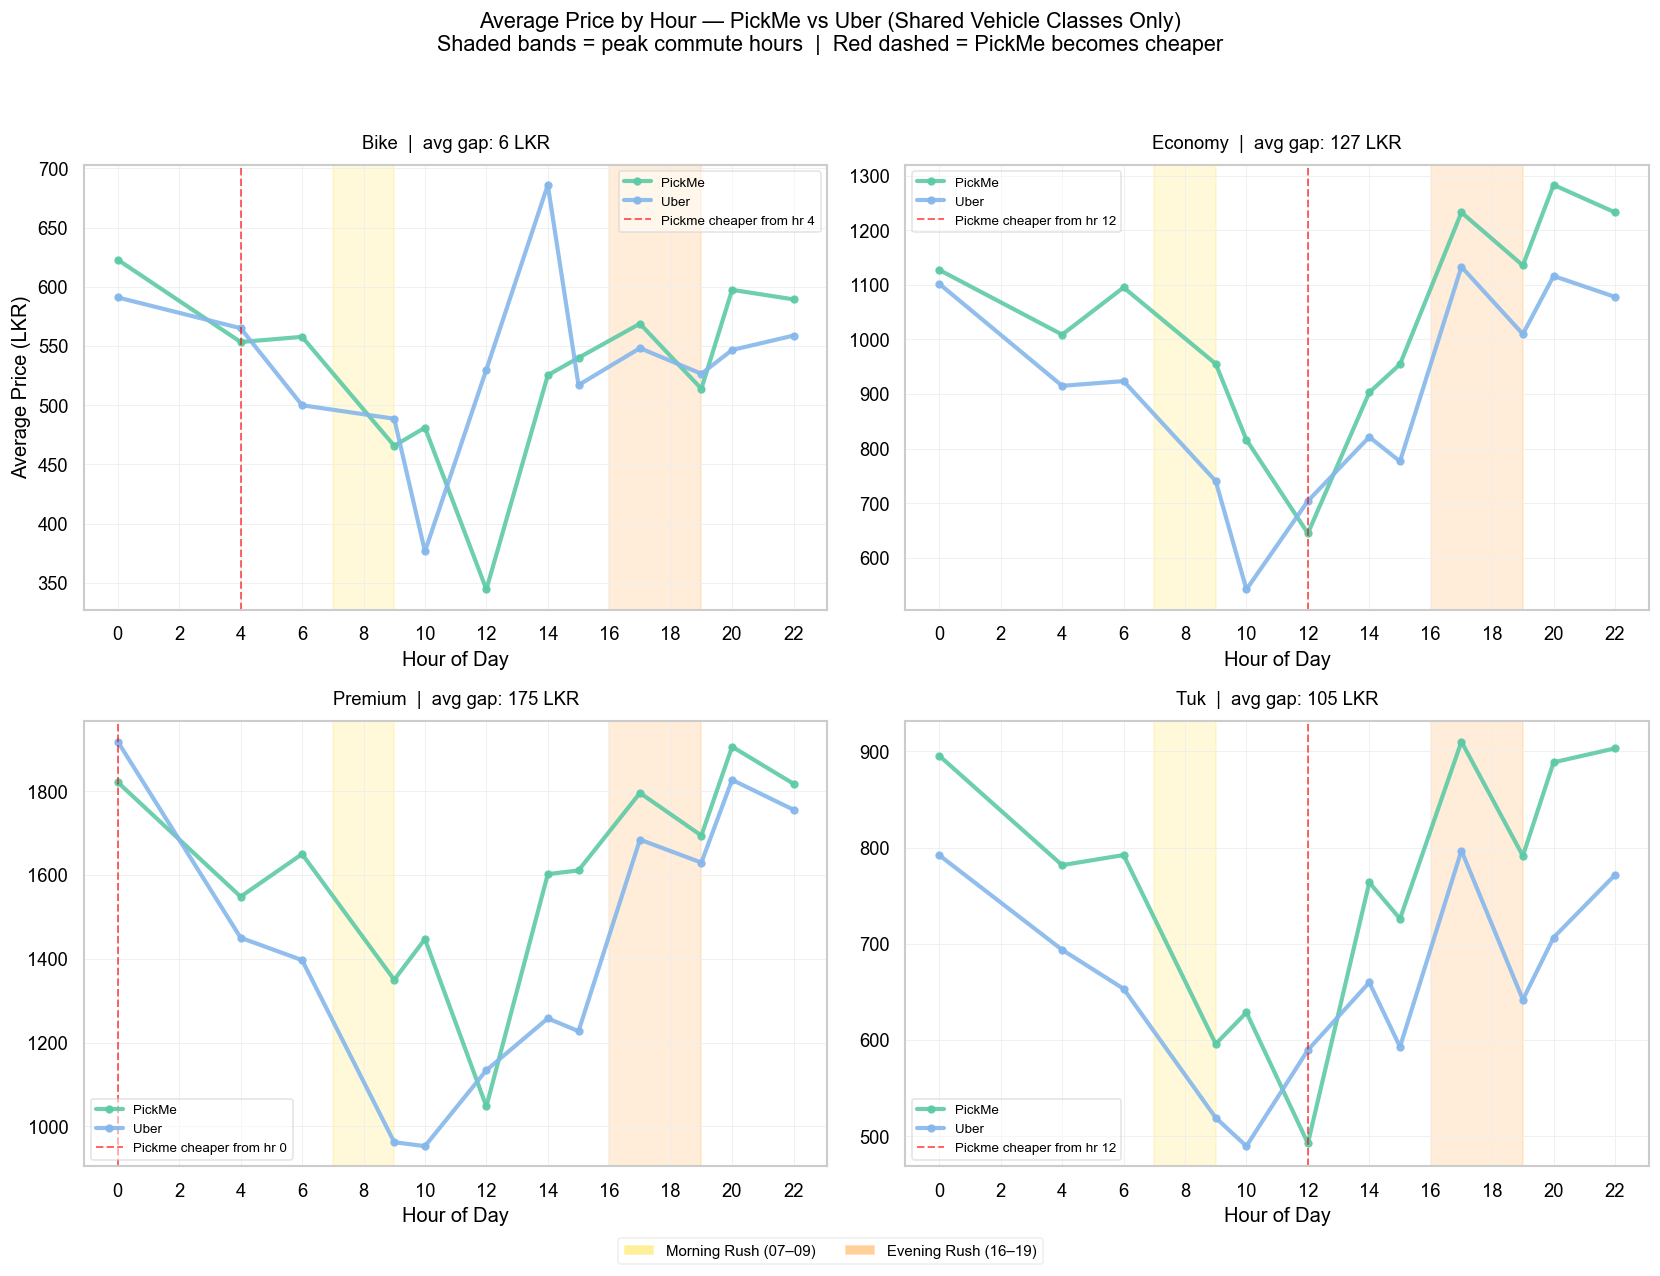

In [2]:
# ── SECTION 1  ────────────────────────────────────────────
import math
from matplotlib.patches import Patch

# ── MUST BE FIRST ────────────────────────────────────────────────
plt.rcParams.update({
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'axes.edgecolor':   '#cccccc',
    'grid.color':       '#eeeeee',
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
})

# ── Data prep ─────────────────────────────────────────────────────
comparable = df[~df['vehicle_class'].isin(['Parcel_Bike', 'Parcel_Tuk'])]

classes_per_platform = (
    comparable.groupby(['platform', 'vehicle_class'])
    .size()
    .reset_index()
    .groupby('vehicle_class')['platform']
    .nunique()
)
shared_classes = classes_per_platform[classes_per_platform == 2].index.tolist()
print(f"Shared vehicle classes: {shared_classes}")

fair = comparable[comparable['vehicle_class'].isin(shared_classes)]

hourly_fair = (
    fair
    .groupby(['hour', 'platform', 'vehicle_class'])['price']
    .mean()
    .reset_index()
    .rename(columns={'price': 'avg_price'})
)

# ── Layout ────────────────────────────────────────────────────────
n_classes = len(shared_classes)
n_cols    = 2
n_rows    = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 5 * n_rows),
    sharey=False
)
axes = axes.flatten()

colors = {'PickMe': '#5DCAA5', 'Uber': '#85B7EB'}

# ── Plot each vehicle class ───────────────────────────────────────
for ax, vehicle in zip(axes, shared_classes):
    subset = hourly_fair[hourly_fair['vehicle_class'] == vehicle]

    # ── Lines ─────────────────────────────────────────────────────
    for platform, group in subset.groupby('platform'):
        ax.plot(
            group['hour'],
            group['avg_price'],
            marker    = 'o',
            label     = platform,
            linewidth = 2.5,
            color     = colors[platform],
            markersize= 4,
            alpha     = 0.9
        )

    # ── Rush hour bands ───────────────────────────────────────────
    ax.axvspan(7,  9,  alpha=0.15, color='#FFD700', zorder=0)
    ax.axvspan(16, 19, alpha=0.15, color='#FF8C00', zorder=0)

    # ── Crossover detection ───────────────────────────────────────
    pickme_avg = subset[subset['platform'] == 'PickMe'].set_index('hour')['avg_price']
    uber_avg   = subset[subset['platform'] == 'Uber'].set_index('hour')['avg_price']
    diff       = pickme_avg - uber_avg

    crossovers = diff[diff < 0].index.tolist()
    if crossovers:
        ax.axvline(
            x         = crossovers[0],
            color     = 'red',
            linewidth = 1.2,
            linestyle = '--',
            alpha     = 0.6,
            label     = f'Pickme cheaper from hr {crossovers[0]}'
        )

    # ── Title with avg gap ────────────────────────────────────────
    avg_gap = abs(diff.mean())
    ax.set_title(f'{vehicle}  |  avg gap: {avg_gap:.0f} LKR', fontsize=11, pad=10)

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Average Price (LKR)' if vehicle == shared_classes[0] else '')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=8, framealpha=0.5)
    ax.grid(True, linewidth=0.5)

# ── Hide unused subplots ──────────────────────────────────────────
for i in range(len(shared_classes), len(axes)):
    axes[i].set_visible(False)

# ── Figure legend for rush bands ─────────────────────────────────
legend_elements = [
    Patch(facecolor='#FFD700', alpha=0.4, label='Morning Rush (07–09)'),
    Patch(facecolor='#FF8C00', alpha=0.4, label='Evening Rush (16–19)'),
]
fig.legend(
    handles       = legend_elements,
    loc           = 'lower center',
    ncol          = 2,
    fontsize      = 9,
    framealpha    = 0.3,
    bbox_to_anchor= (0.5, -0.02)
)

fig.suptitle(
    'Average Price by Hour — PickMe vs Uber (Shared Vehicle Classes Only)\n'
    'Shaded bands = peak commute hours  |  Red dashed = PickMe becomes cheaper',
    fontsize=13, y=1.03
)

plt.tight_layout()
plt.savefig(
    '../data/processed/eda_01_hourly_price_fair.png',
    dpi=150, bbox_inches='tight', facecolor='white'
)
plt.show()

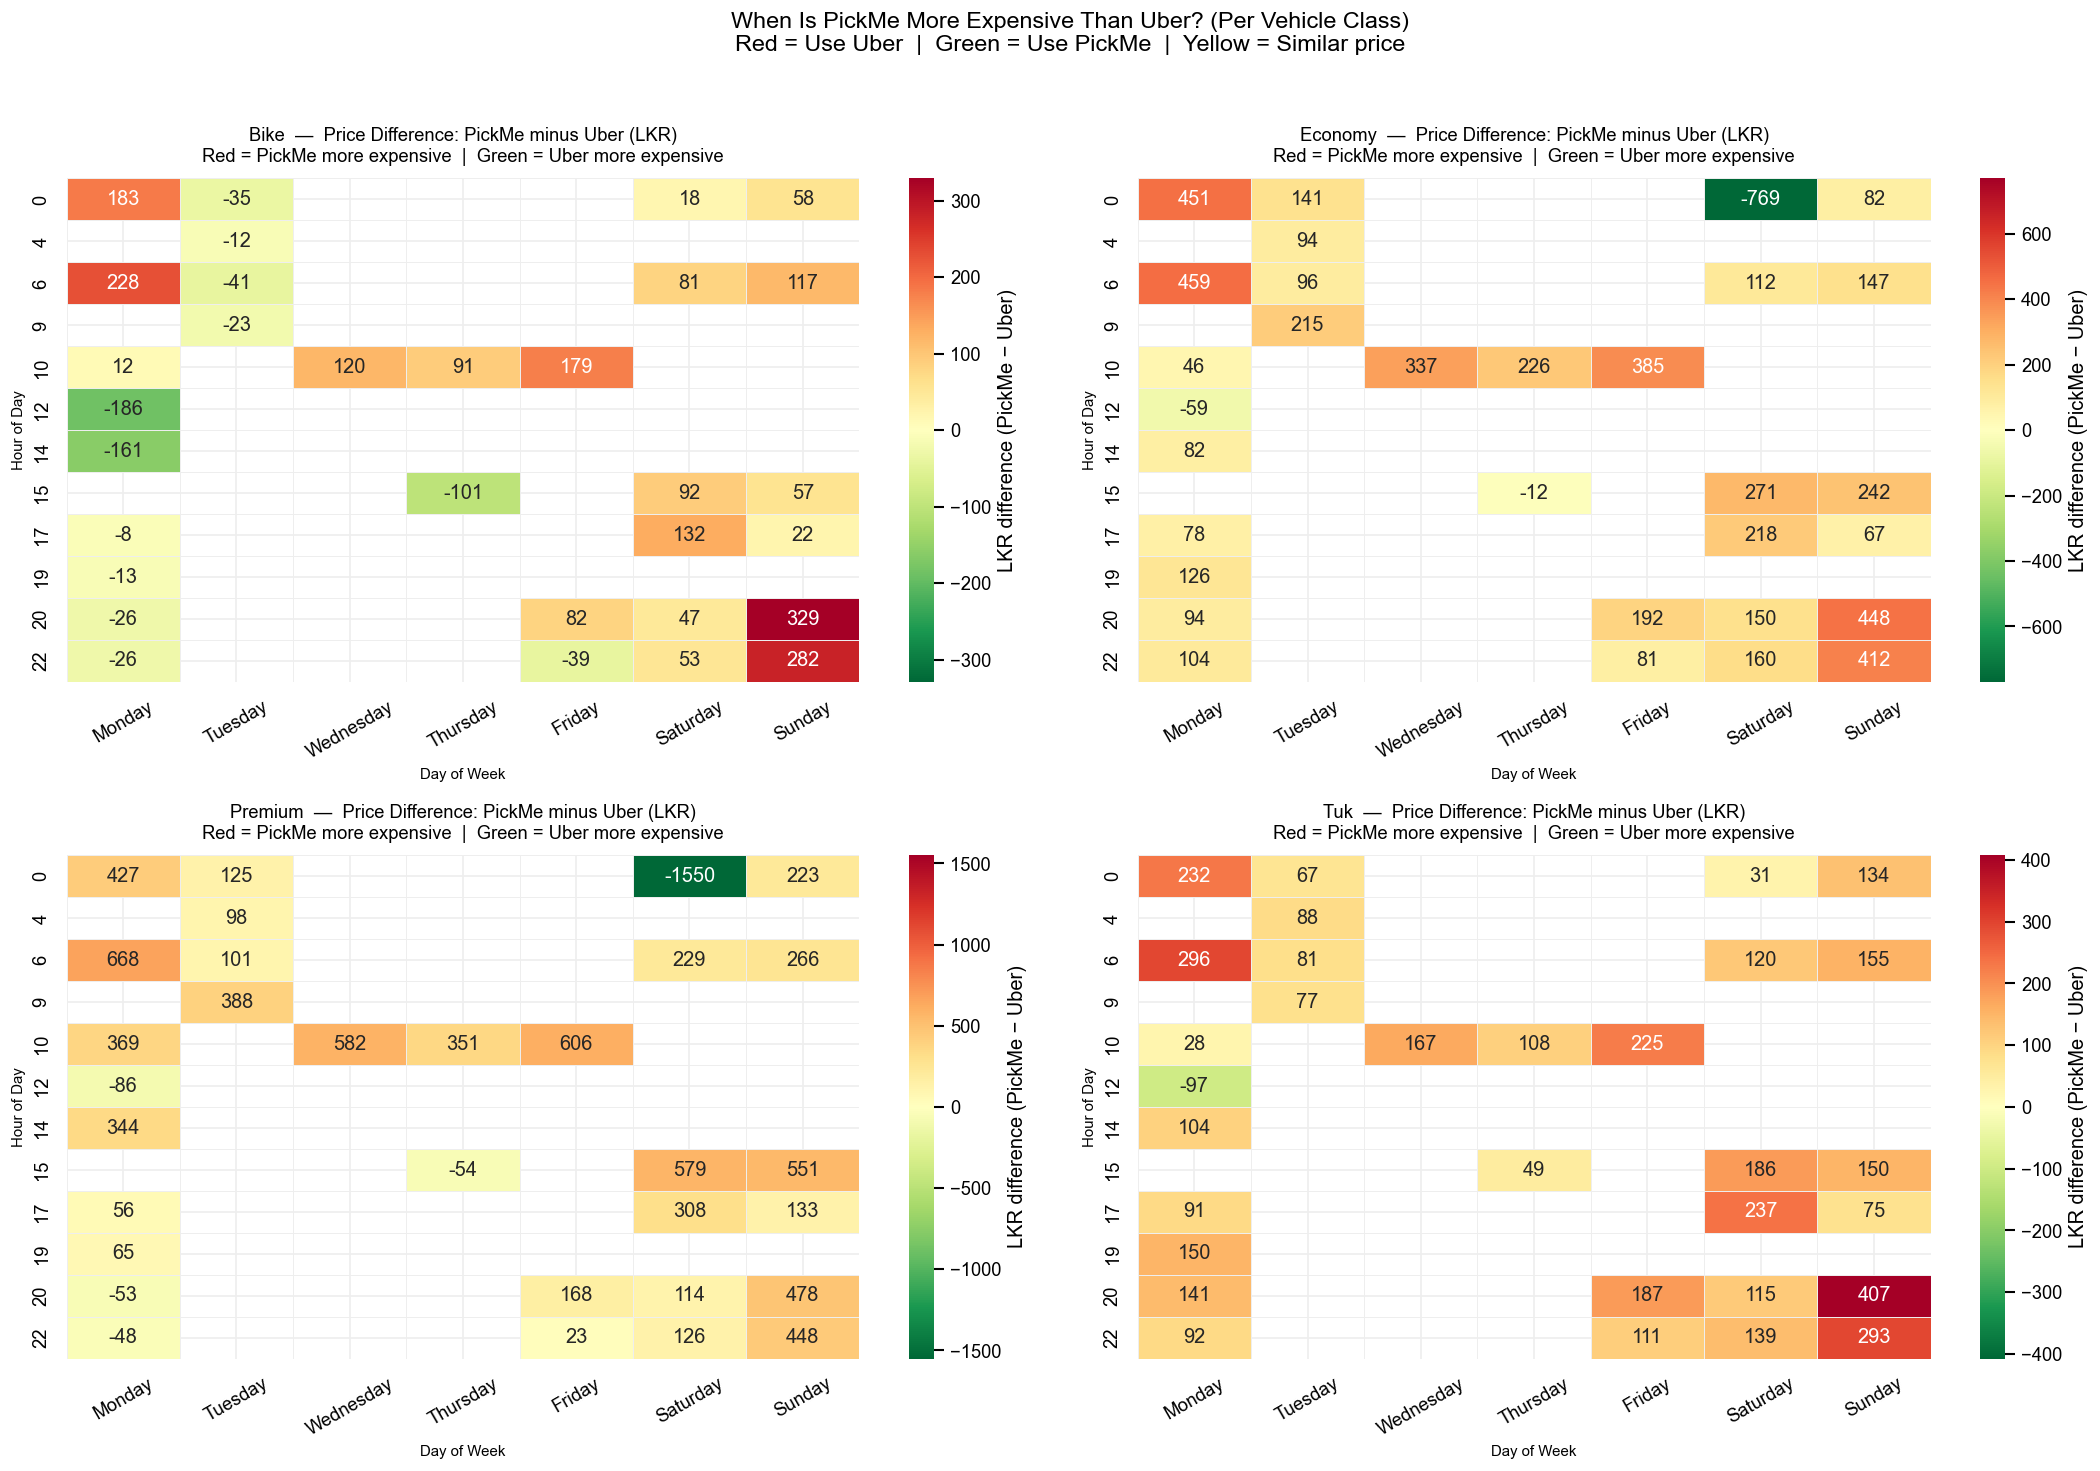

In [4]:
# ── SECTION 2 — PER VEHICLE CLASS HEATMAP ────────────────────────
# Question: Are there moments where one platform is significantly more expensive?

plt.rcParams.update({
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
})

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

n_cols = 2
n_rows = math.ceil(len(shared_classes) / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 6 * n_rows)
)
axes = axes.flatten()

for ax, vehicle in zip(axes, shared_classes):

    # Filter to this vehicle class only
    vehicle_df = fair[fair['vehicle_class'] == vehicle]

    # Average price per hour × day per platform
    pivot_pickme = (
        vehicle_df[vehicle_df['platform'] == 'PickMe']
        .groupby(['hour', 'day_name'])['price']
        .mean()
    )
    pivot_uber = (
        vehicle_df[vehicle_df['platform'] == 'Uber']
        .groupby(['hour', 'day_name'])['price']
        .mean()
    )

    # Difference — positive = Uber more expensive
    diff = (pivot_pickme - pivot_uber).reset_index()

    # Reshape for heatmap
    heatmap_data = (
        diff.pivot(index='hour', columns='day_name', values='price')
        .reindex(columns=day_order)
    )

    # Dynamic color scale — center at 0, symmetric around it
    abs_max = heatmap_data.abs().max().max()

    sns.heatmap(
        heatmap_data,
        cmap      = 'RdYlGn_r',
        center    = 0,
        vmin      = -abs_max,    # ← symmetric scale per vehicle
        vmax      =  abs_max,
        annot     = True,
        fmt       = '.0f',
        ax        = ax,
        linewidths= 0.4,
        linecolor = '#eeeeee',
        cbar_kws  = {'label': 'LKR difference (PickMe − Uber)'}
    )

    ax.set_title(
    f'{vehicle}  —  Price Difference: PickMe minus Uber (LKR)\n'
    f'Red = PickMe more expensive  |  Green = Uber more expensive',
    fontsize=11, pad=10
    )
    ax.set_xlabel('Day of Week', fontsize=9)
    ax.set_ylabel('Hour of Day', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

# Hide unused subplots
for i in range(len(shared_classes), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    'When Is PickMe More Expensive Than Uber? (Per Vehicle Class)\n'
    'Red = Use Uber  |  Green = Use PickMe  |  Yellow = Similar price',
    fontsize=14, y=1.02
)

plt.tight_layout()
plt.savefig(
    '../data/processed/eda_02_price_diff_heatmap.png',
    dpi=150, bbox_inches='tight', facecolor='white'
)
plt.show()

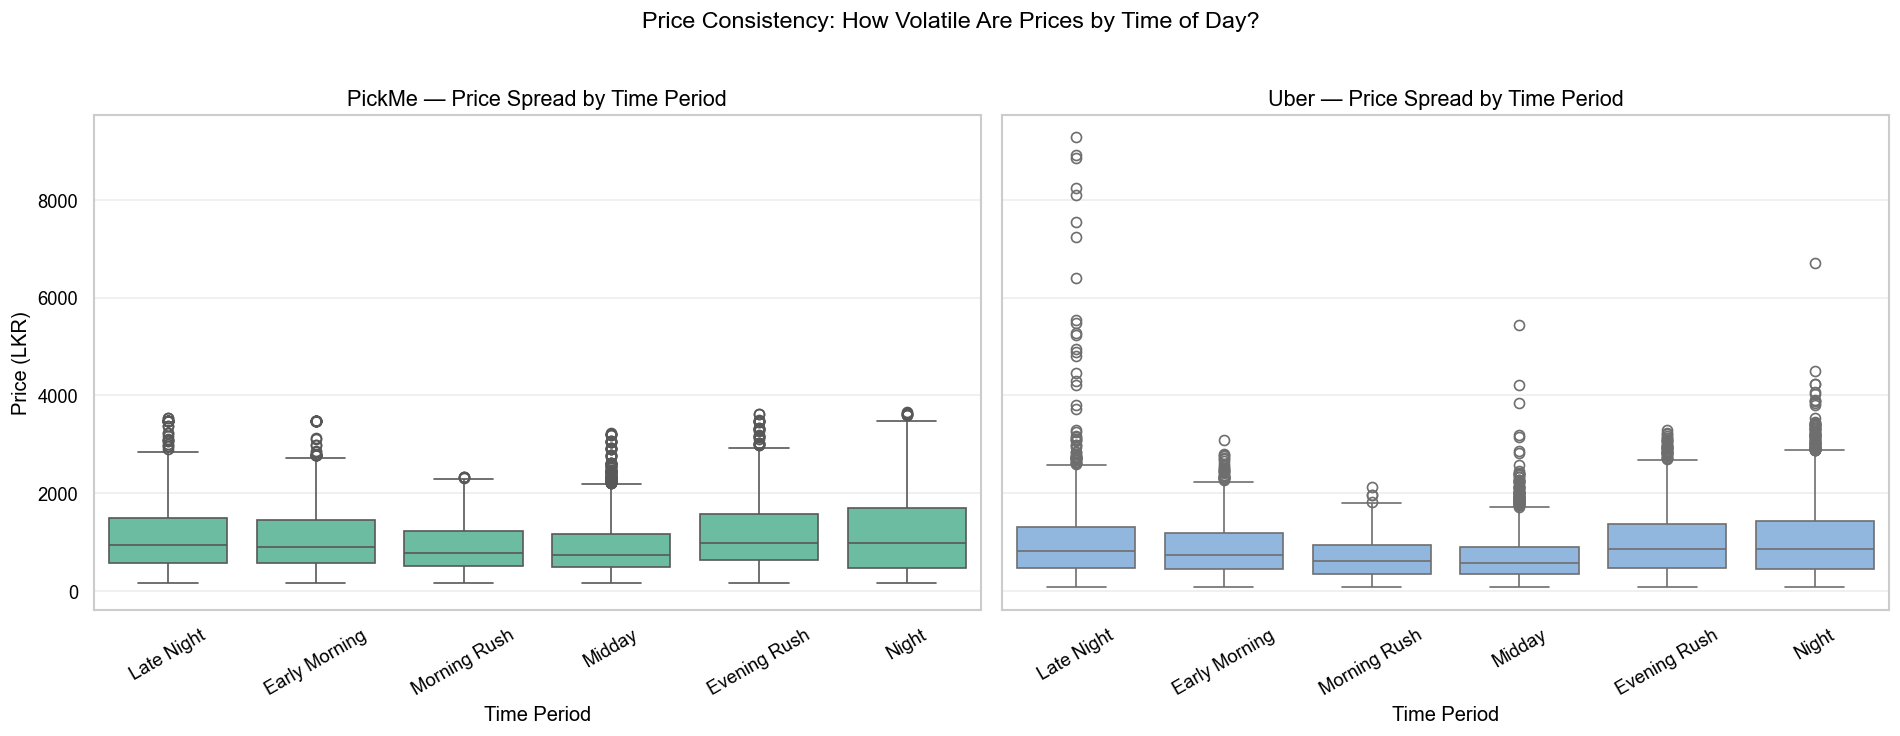

In [5]:
# ── SECTION 3 ────────────────────────────────────────────────────
# Question: How consistent are prices — volatile or predictable?
# Technique: Box plot — price spread per platform per time period

# Order time periods logically
period_order = [
    'Late Night', 'Early Morning', 'Morning Rush',
    'Midday', 'Evening Rush', 'Night'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, platform in zip(axes, ['PickMe', 'Uber']):
    platform_data = comparable[comparable['platform'] == platform]

    # YOUR TASK: use seaborn boxplot
    # x = time_period, y = price, data = platform_data
    # order = period_order, ax = ax
    sns.boxplot(
        x     = "time_period",
        y     = "price",
        data  = platform_data,
        order = period_order,
        ax    = ax,
        color = '#5DCAA5' if platform == 'PickMe' else '#85B7EB'
    )

    ax.set_title(f'{platform} — Price Spread by Time Period', fontsize=13)
    ax.set_xlabel('Time Period')
    ax.set_ylabel('Price (LKR)' if platform == 'PickMe' else '')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Price Consistency: How Volatile Are Prices by Time of Day?',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_03_price_volatility.png', dpi=150)
plt.show()

# OBSERVATION: "___________"

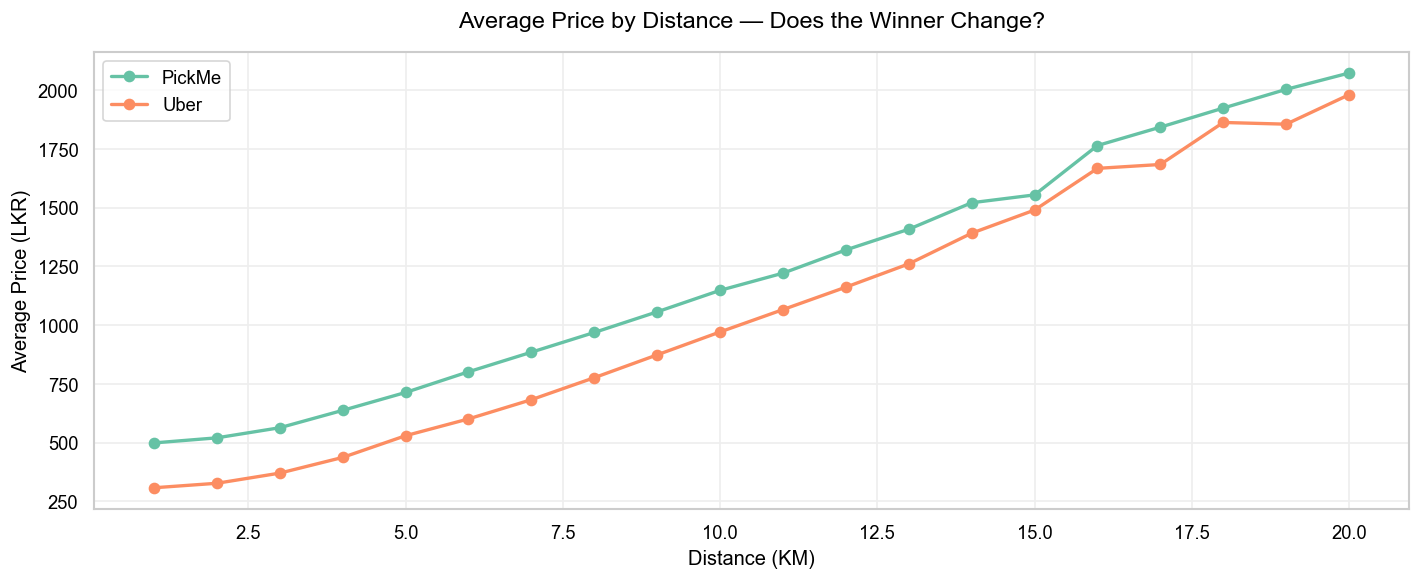

In [6]:
# ── SECTION 4 — BONUS ────────────────────────────────────────────
# Distance vs Price — does the winner change for long vs short trips?

fig, ax = plt.subplots()

for platform, group in comparable.groupby('platform'):
    # YOUR TASK: group by Distance(KM) and platform, get mean price
    # then plot distance on x, avg price on y
    dist_avg = (
        group.groupby('Distance(KM)')['price']
        .mean()
        .reset_index()
    )
    ax.plot(
        dist_avg['Distance(KM)'],
        dist_avg['price'],
        marker  = 'o',
        label   = platform,
        linewidth=2
    )

ax.set_title('Average Price by Distance — Does the Winner Change?', fontsize=14, pad=15)
ax.set_xlabel('Distance (KM)')
ax.set_ylabel('Average Price (LKR)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/eda_04_distance_price.png', dpi=150)
plt.show()

# OBSERVATION: "___________"